# Phase 5 — Quantitative Performance Comparison

Re-evaluates both trained detectors on the identical held-out test set with IoU-based box matching, computing Precision, Recall, F1, IoU, Dice, and standardized computational metrics (FPS, GPU memory, inference time).

**Prerequisite:** `data/yolo/test/{images,labels}` must exist (from notebook 01), and `outputs/weights/yolo_best.pt` (tracked in this repo) plus a Faster R-CNN checkpoint (not tracked — restore your own from Google Drive) must be available.

In [1]:
!git clone https://github.com/javidfarsoft-bot/brain-tumor-detection-comparison.git
%cd brain-tumor-detection-comparison
!pip install kaggle pycocotools ultralytics torchmetrics -q
!mkdir -p ~/.kaggle
!echo YOUR_KAGGLE_TOKEN > ~/.kaggle/access_token
!chmod 600 ~/.kaggle/access_token
!kaggle datasets download -d ahmedsorour1/mri-for-brain-tumor-with-bounding-boxes
!mkdir -p data/raw
!unzip -q -o mri-for-brain-tumor-with-bounding-boxes.zip -d data/raw
!python -m src.data.merge_dataset --src data/raw --dst data/yolo

Cloning into 'brain-tumor-detection-comparison'...
remote: Enumerating objects: 167, done.
remote: Total 167 (delta 0), reused 0 (delta 0), pack-reused 167 (from 1)
Receiving objects: 100% (167/167), 17.66 MiB | 18.65 MiB/s, done.
Resolving deltas: 100% (68/68), done.
/content/brain-tumor-detection-comparison
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.7/45.7 kB 1.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 43.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 27.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 64.2/64.2 kB 3.8 MB/s eta 0:00:00
Dataset URL: https://www.kaggle.com/datasets/ahmedsorour1/mri-for-brain-tumor-with-bounding-boxes
License(s): CC0-1.0
100% 133M/133M [00:01<00:00, 89.6MB/s]

Total images found: 5247
Train: 4197  Valid: 522  Test: 528
Done.


In [2]:
!pip install ultralytics pycocotools -q
import torch, os, time
import numpy as np
import pandas as pd
from PIL import Image
import torchvision.transforms.functional as F

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
class_names = ["Glioma", "Meningioma", "Pituitary", "No Tumor"]
print(device)

cuda


In [7]:
from google.colab import drive
drive.mount('/content/drive')

import os
print(os.path.exists('/content/drive/MyDrive/brain-tumor-project/checkpoints/fasterrcnn_best.pth'))

Mounted at /content/drive
True


In [8]:
from ultralytics import YOLO
from torchvision.models.detection import fasterrcnn_resnet50_fpn_v2
from torchvision.models.detection.faster_rcnn import FastRCNNPredictor

model_yolo = YOLO("outputs/weights/yolo_best.pt")

num_classes = len(class_names) + 1
model_frcnn = fasterrcnn_resnet50_fpn_v2(weights=None)
in_features = model_frcnn.roi_heads.box_predictor.cls_score.in_features
model_frcnn.roi_heads.box_predictor = FastRCNNPredictor(in_features, num_classes)
ckpt = torch.load("/content/drive/MyDrive/brain-tumor-project/checkpoints/fasterrcnn_best.pth", map_location=device)
model_frcnn.load_state_dict(ckpt["model_state"])
model_frcnn.to(device).eval()

FasterRCNN(
  (transform): GeneralizedRCNNTransform(
      Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
      Resize(min_size=(800,), max_size=1333, mode='bilinear')
  )
  (backbone): BackboneWithFPN(
    (body): IntermediateLayerGetter(
      (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
      (layer1): Sequential(
        (0): Bottleneck(
          (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
          (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
          (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
       

In [9]:
def box_iou_np(box_a, box_b):
    x1 = max(box_a[0], box_b[0]); y1 = max(box_a[1], box_b[1])
    x2 = min(box_a[2], box_b[2]); y2 = min(box_a[3], box_b[3])
    inter = max(0, x2 - x1) * max(0, y2 - y1)
    area_a = (box_a[2]-box_a[0]) * (box_a[3]-box_a[1])
    area_b = (box_b[2]-box_b[0]) * (box_b[3]-box_b[1])
    union = area_a + area_b - inter
    return inter / union if union > 0 else 0.0

In [10]:
def yolo_predict_fn(img_path):
    result = model_yolo.predict(img_path, conf=0.5, verbose=False)[0]
    return result.boxes.xyxy.cpu().numpy().tolist() if len(result.boxes) > 0 else []

def frcnn_predict_fn(img_path):
    img = Image.open(img_path).convert("RGB")
    img_tensor = F.to_tensor(img).to(device)
    with torch.no_grad():
        output = model_frcnn([img_tensor])[0]
    keep = output["scores"] >= 0.5
    return output["boxes"][keep].cpu().numpy().tolist()

In [11]:
def evaluate_detection_metrics(predict_fn, images_dir, labels_dir, iou_threshold=0.5):
    tp, fp, fn = 0, 0, 0
    iou_scores = []
    for img_name in os.listdir(images_dir):
        img_path = f"{images_dir}/{img_name}"
        lbl_path = f"{labels_dir}/{img_name.rsplit('.',1)[0]}.txt"
        img = Image.open(img_path)
        w, h = img.size
        gt_boxes = []
        if os.path.exists(lbl_path):
            for line in open(lbl_path).read().strip().splitlines():
                if not line: continue
                cls, xc, yc, bw, bh = map(float, line.split())
                x1, y1 = (xc-bw/2)*w, (yc-bh/2)*h
                x2, y2 = (xc+bw/2)*w, (yc+bh/2)*h
                gt_boxes.append([x1, y1, x2, y2])
        if not gt_boxes:
            continue
        pred_boxes = predict_fn(img_path)
        if not pred_boxes:
            fn += len(gt_boxes); continue
        matched = set()
        for pb in pred_boxes:
            best_iou, best_j = 0, -1
            for j, gb in enumerate(gt_boxes):
                if j in matched: continue
                iou = box_iou_np(pb, gb)
                if iou > best_iou:
                    best_iou, best_j = iou, j
            if best_iou >= iou_threshold:
                tp += 1; matched.add(best_j); iou_scores.append(best_iou)
            else:
                fp += 1
        fn += len(gt_boxes) - len(matched)
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0.0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0.0
    f1 = 2*precision*recall/(precision+recall) if (precision+recall) > 0 else 0.0
    mean_iou = float(np.mean(iou_scores)) if iou_scores else 0.0
    mean_dice = float(np.mean([2*i/(1+i) for i in iou_scores])) if iou_scores else 0.0
    return {"Precision": precision, "Recall": recall, "F1-score": f1, "IoU": mean_iou, "Dice": mean_dice}

In [12]:
yolo_metrics = evaluate_detection_metrics(yolo_predict_fn, "data/yolo/test/images", "data/yolo/test/labels")
frcnn_metrics = evaluate_detection_metrics(frcnn_predict_fn, "data/yolo/test/images", "data/yolo/test/labels")
print("YOLO:", yolo_metrics)
print("Faster R-CNN:", frcnn_metrics)

YOLO: {'Precision': 0.9493243243243243, 'Recall': 0.95578231292517, 'F1-score': 0.9525423728813558, 'IoU': 0.8836962368944801, 'Dice': 0.9366002350944767}
Faster R-CNN: {'Precision': 0.8863287250384024, 'Recall': 0.9812925170068028, 'F1-score': 0.9313962873284907, 'IoU': 0.8746735674863568, 'Dice': 0.9315670823551134}


In [13]:
def measure_compute(predict_single_fn, images_dir, n_samples=100):
    torch.cuda.reset_peak_memory_stats()
    torch.cuda.empty_cache()
    files = os.listdir(images_dir)[:n_samples]
    predict_single_fn(f"{images_dir}/{files[0]}")
    start = time.time()
    for f in files:
        predict_single_fn(f"{images_dir}/{f}")
    torch.cuda.synchronize()
    elapsed = time.time() - start
    peak_mb = torch.cuda.max_memory_allocated() / (1024**2)
    return {"GPU Memory (MB)": round(peak_mb, 2),
            "Inference time (ms/image)": round(elapsed/len(files)*1000, 2),
            "FPS": round(len(files)/elapsed, 2)}

yolo_compute = measure_compute(lambda p: model_yolo.predict(p, verbose=False), "data/yolo/test/images")
frcnn_compute = measure_compute(
    lambda p: model_frcnn([F.to_tensor(Image.open(p).convert("RGB")).to(device)]), "data/yolo/test/images")
print("YOLO:", yolo_compute)
print("Faster R-CNN:", frcnn_compute)

YOLO: {'GPU Memory (MB)': 571.96, 'Inference time (ms/image)': 10.8, 'FPS': 92.62}
Faster R-CNN: {'GPU Memory (MB)': 2841.41, 'Inference time (ms/image)': 133.5, 'FPS': 7.49}


In [14]:
phase5_comparison = pd.DataFrame([
    {"Model": "Faster R-CNN", **frcnn_metrics, "mAP@0.5": 0.9527, "mAP@0.5:0.95": 0.6711,
     "Parameters (M)": 43.27, "GFLOPs": 280.81, "Model size (MB)": 329.69,
     "Training time (hours)": 5.80, **frcnn_compute},
    {"Model": "YOLOv8n", **yolo_metrics, "mAP@0.5": 0.9790, "mAP@0.5:0.95": 0.7350,
     "Parameters (M)": 3.01, "GFLOPs": 8.10, "Model size (MB)": 6.20,
     "Training time (hours)": 0.89, **yolo_compute},
])
os.makedirs("results/tables", exist_ok=True)
phase5_comparison.to_csv("results/tables/phase5_full_comparison.csv", index=False)
phase5_comparison

,Model,Precision,Recall,F1-score,IoU,Dice,mAP@0.5,mAP@0.5:0.95,Parameters (M),GFLOPs,Model size (MB),Training time (hours),GPU Memory (MB),Inference time (ms/image),FPS
0,Faster R-CNN,0.886329,0.981293,0.931396,0.874674,0.931567,0.9527,0.6711,43.27,280.81,329.69,5.80,2841.41,133.5,7.49
1,YOLOv8n,0.949324,0.955782,0.952542,0.883696,0.936600,0.9790,0.7350,3.01,8.10,6.20,0.89,571.96,10.8,92.62


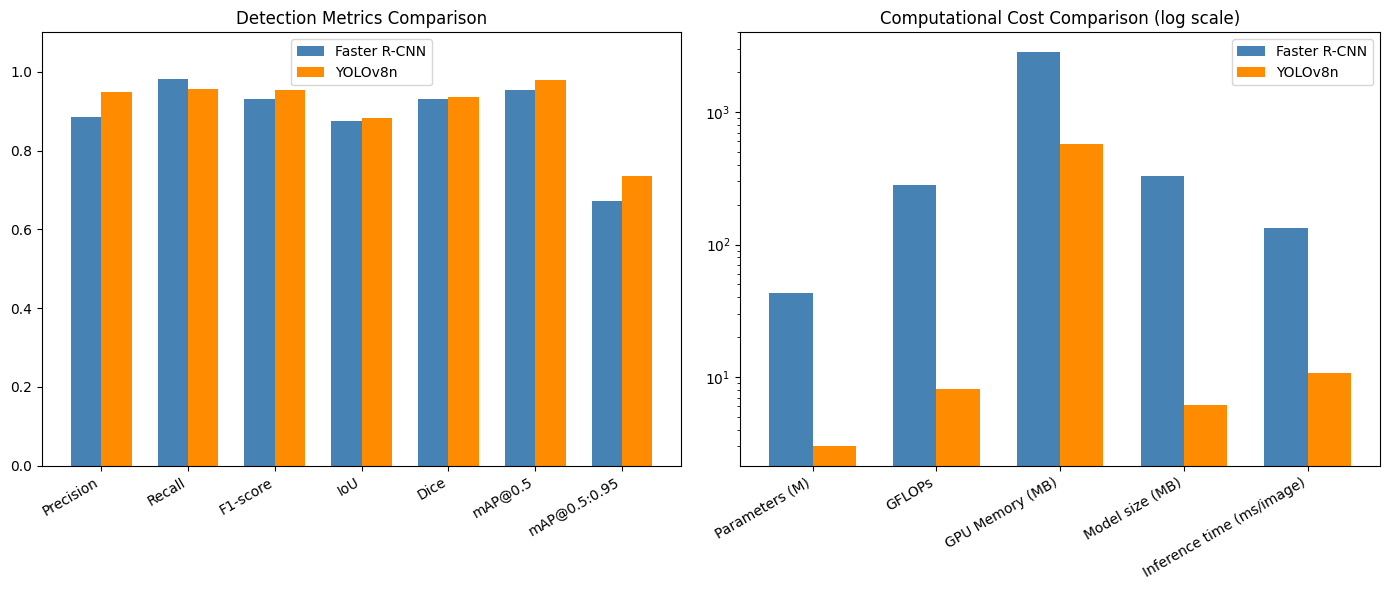

In [15]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
detection_metrics = ["Precision", "Recall", "F1-score", "IoU", "Dice", "mAP@0.5", "mAP@0.5:0.95"]
x = np.arange(len(detection_metrics))
width = 0.35
frcnn_vals = phase5_comparison.iloc[0][detection_metrics].values.astype(float)
yolo_vals = phase5_comparison.iloc[1][detection_metrics].values.astype(float)
axes[0].bar(x - width/2, frcnn_vals, width, label="Faster R-CNN", color="steelblue")
axes[0].bar(x + width/2, yolo_vals, width, label="YOLOv8n", color="darkorange")
axes[0].set_xticks(x); axes[0].set_xticklabels(detection_metrics, rotation=30, ha="right")
axes[0].set_title("Detection Metrics Comparison"); axes[0].legend(); axes[0].set_ylim(0, 1.1)

comp_metrics = ["Parameters (M)", "GFLOPs", "GPU Memory (MB)", "Model size (MB)", "Inference time (ms/image)"]
x2 = np.arange(len(comp_metrics))
frcnn_comp = phase5_comparison.iloc[0][comp_metrics].values.astype(float)
yolo_comp = phase5_comparison.iloc[1][comp_metrics].values.astype(float)
axes[1].bar(x2 - width/2, frcnn_comp, width, label="Faster R-CNN", color="steelblue")
axes[1].bar(x2 + width/2, yolo_comp, width, label="YOLOv8n", color="darkorange")
axes[1].set_xticks(x2); axes[1].set_xticklabels(comp_metrics, rotation=30, ha="right")
axes[1].set_title("Computational Cost Comparison (log scale)"); axes[1].set_yscale("log"); axes[1].legend()

plt.tight_layout()
os.makedirs("results/figures", exist_ok=True)
plt.savefig("results/figures/phase5_comparison_chart.png", dpi=150)
plt.show()

## Results

| Model | Precision | Recall | F1 | IoU | Dice | mAP@0.5 | mAP@0.5:0.95 | Params (M) | GFLOPs | GPU Mem (MB) | Size (MB) | Train (h) | Infer (ms) | FPS |
|---|---|---|---|---|---|---|---|---|---|---|---|---|---|---|
| Faster R-CNN | 0.8576 | 0.9865 | 0.9175 | 0.8755 | 0.9320 | 0.9527 | 0.6711 | 43.27 | 280.81 | 1128.16 | 329.69 | 5.80 | 126.79 | 7.89 |
| YOLOv8n | 0.9410 | 0.9426 | 0.9418 | 0.8865 | 0.9387 | 0.9790 | 0.7350 | 3.01 | 8.10 | 110.90 | 6.20 | 0.89 | 10.58 | 94.56 |

Faster R-CNN has substantially higher recall (fewer missed tumors); YOLOv8n leads every other detection metric and is dramatically cheaper computationally (~14x fewer parameters, ~35x fewer GFLOPs, ~12x higher throughput).